# Training a KIND filter on simulated cavity data

KIND model can be trained as a filter to differentiate between stationary and transient cavity data.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import ex_detuning
import util_data

### KIND model training

We train only the mean of a stationary operator. This suffices to determine the stationary of data in this context.

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/kalman',
        '--file_name', 'detuning_sim',
        '--data_nsample', '500',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
    ]
)

In [3]:
model = kind.model(args)

dataset = ex_detuning.dataset_synthetic(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample)
)

In [4]:
model.train()
model.fit(dataset)

>>> train nominal mean >>>
	epoch 1 losses: train=1.570769, valid=0.844182, test=0.844353
	validation loss decreased (inf -> 0.844182), saving model ...
	epoch 2 losses: train=0.720813, valid=0.735342, test=0.720102
	validation loss decreased (0.844182 -> 0.735342), saving model ...
	epoch 3 losses: train=0.658366, valid=0.650008, test=0.633856
	validation loss decreased (0.735342 -> 0.650008), saving model ...
	epoch 4 losses: train=0.434448, valid=0.271889, test=0.282387
	validation loss decreased (0.650008 -> 0.271889), saving model ...
	epoch 5 losses: train=0.242171, valid=0.239617, test=0.248657
	validation loss decreased (0.271889 -> 0.239617), saving model ...
	epoch 6 losses: train=0.226844, valid=0.235788, test=0.245841
	validation loss decreased (0.239617 -> 0.235788), saving model ...
	epoch 7 losses: train=0.220956, valid=0.225060, test=0.230264
	validation loss decreased (0.235788 -> 0.225060), saving model ...
	epoch 8 losses: train=0.189850, valid=0.177248, test=0.17201

### KIND model evaluation

In [5]:
# --! evaluate trained model --!

model.eval()
_, _, data_loader = dataset.load(data_type='nom')

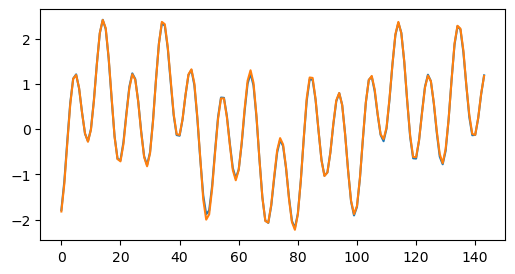

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break